<a href="https://colab.research.google.com/github/edaska/Stochastic_Processes_-_Optimization_in_Machine_Learning/blob/main/lab2/Stochastic_Processes_%26_Optimization_in_Machine_Learning_(Lab_2_Autoencoders).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exercise on Autoencoders**

<p>Within the scope of this exercise, you will examine how an autoencoder works for the classification of a dataset.</p>



In [1]:
# train autoencoder for classification with no compression in the bottleneck layer
from sklearn.datasets import make_classification
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow import keras
from keras.models import Model
from keras.layers import Input
from keras.layers import Dense
from keras.layers import LeakyReLU
from keras.layers import BatchNormalization
from matplotlib import pyplot

We will use the scikit-learn <i>make_classification()</i> function to define a synthetic classification dataset (2 classes) with 100 input features (columns) and 1,000 samples (rows).

Attention: In the given problem, 10% of the samples are informative.

In [2]:
# synthetic classification dataset
from sklearn.datasets import make_classification
# define dataset
X, y = make_classification(n_samples=1000, n_features=100, n_informative=10, n_redundant=90, random_state=1)
# number of input columns
n_inputs = X.shape[1]
# summarize the dataset
print(X.shape, y.shape)

(1000, 100) (1000,)


Next, we will develop an ([Multilayer Perceptron - MLP](https://en.wikipedia.org/wiki/Multilayer_perceptron)) autoencoder model.

The autoencoder consists of two parts: the encoder and the decoder.

Once the autoencoder is trained, the decoder will not be used again, and we keep only the encoder to compress input samples into the vectors produced by the bottleneck.

Before defining and fitting the model, we will split the data into training and test sets and scale the input data by normalizing the values to the range 0–1.


In [3]:
# split into train test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)
# scale data
t = MinMaxScaler()
t.fit(X_train)
X_train = t.transform(X_train)
X_test = t.transform(X_test)

We will define the encoder to have two hidden layers: the first with twice the number of input dimensions (e.g., 200) and the second with  the original number of dimensions (100).


In [33]:
# define encoder
visible = Input(shape=(n_inputs,))
# encoder level 1
e = Dense(n_inputs*2)(visible)
e = BatchNormalization()(e)
e = LeakyReLU()(e)
# encoder level 2
e = Dense(n_inputs)(e)
e = BatchNormalization()(e)
e = LeakyReLU()(e)
# bottleneck
n_bottleneck = 15
bottleneck = Dense(n_bottleneck)(e)

Next, we define the decoder. The decoder will have the reverse structure of the encoder.

In [34]:
# define decoder, level 1
d = Dense(n_inputs)(bottleneck)
d = BatchNormalization()(d)
d = LeakyReLU()(d)
# decoder level 2
d = Dense(n_inputs*2)(d)
d = BatchNormalization()(d)
d = LeakyReLU()(d)
# output layer
output = Dense(n_inputs, activation='linear')(d)
# define autoencoder model
model = Model(inputs=visible, outputs=output)

Next, we compile our model.

In [35]:
# compile autoencoder model
model.compile(optimizer='adam', loss='mse')

Next, we can train the model to reproduce the input data and monitor the model’s performance compared to the test set.

Question 1: What is the difference between mini-batches and epochs?


In [36]:
# fit the autoencoder model to reconstruct input
history = model.fit(X_train, X_train, epochs=200, batch_size=16, verbose=2, validation_data=(X_test,X_test))

Epoch 1/200
42/42 - 2s - 55ms/step - loss: 0.2203 - val_loss: 0.1922
Epoch 2/200
42/42 - 0s - 4ms/step - loss: 0.0365 - val_loss: 0.1142
Epoch 3/200
42/42 - 0s - 4ms/step - loss: 0.0233 - val_loss: 0.0601
Epoch 4/200
42/42 - 0s - 4ms/step - loss: 0.0193 - val_loss: 0.0339
Epoch 5/200
42/42 - 0s - 4ms/step - loss: 0.0160 - val_loss: 0.0218
Epoch 6/200
42/42 - 0s - 4ms/step - loss: 0.0139 - val_loss: 0.0148
Epoch 7/200
42/42 - 0s - 4ms/step - loss: 0.0133 - val_loss: 0.0120
Epoch 8/200
42/42 - 0s - 4ms/step - loss: 0.0136 - val_loss: 0.0091
Epoch 9/200
42/42 - 0s - 4ms/step - loss: 0.0130 - val_loss: 0.0079
Epoch 10/200
42/42 - 0s - 4ms/step - loss: 0.0109 - val_loss: 0.0076
Epoch 11/200
42/42 - 0s - 7ms/step - loss: 0.0105 - val_loss: 0.0059
Epoch 12/200
42/42 - 0s - 4ms/step - loss: 0.0099 - val_loss: 0.0089
Epoch 13/200
42/42 - 0s - 4ms/step - loss: 0.0102 - val_loss: 0.0059
Epoch 14/200
42/42 - 0s - 4ms/step - loss: 0.0088 - val_loss: 0.0072
Epoch 15/200
42/42 - 0s - 4ms/step - loss:

Epoch: An epoch represents one complete pass of the entire training dataset through the neural network. If we set, for example, our training to epochs=200, it means the model will see and learn from the full dataset 200 separate times.

Mini-batch: A mini-batch is a smaller, manageable subset of the training dataset. Instead of passing all the data through the network at once (which requires too much memory) or one sample at a time (which is very slow), the data is divided into these smaller chunks. The model processes one mini-batch, updates its internal weights, and then moves on to the next.

Below are the learning curves for the train and test dataset.

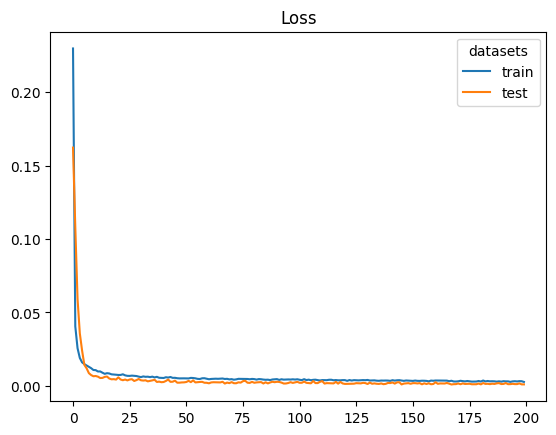

In [8]:
# plot loss / bottleneck = 50
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend(title = "datasets")
pyplot.title("Loss")
pyplot.show()

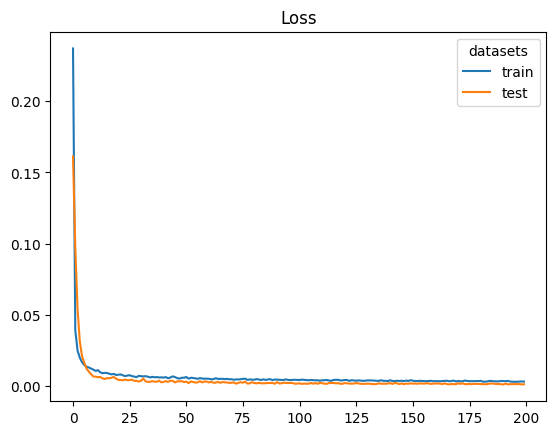

In [13]:
# plot loss / bottleneck = 25
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend(title = "datasets")
pyplot.title("Loss")
pyplot.show()

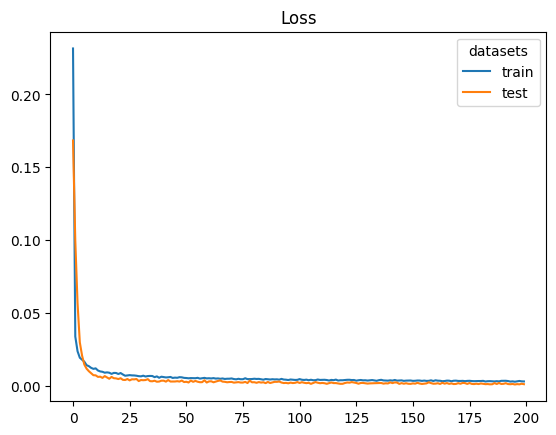

In [18]:
# plot loss / bottleneck = 15
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend(title = "datasets")
pyplot.title("Loss")
pyplot.show()

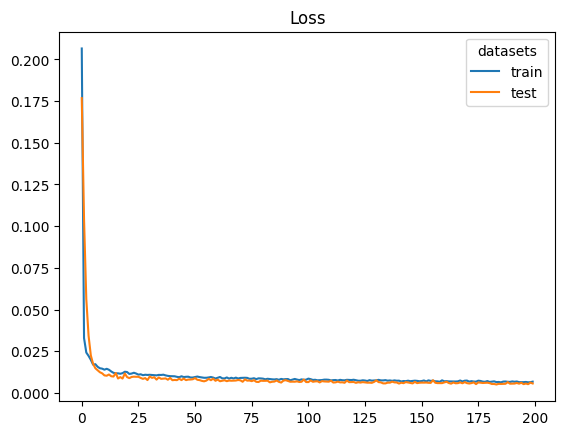

In [24]:
# plot loss / bottleneck = 5
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend(title = "datasets")
pyplot.title("Loss")
pyplot.show()

Question 2: Try running the model with a bottleneck of (a) 25 and (b) 15. What do you observe regarding the model’s results?


Bottleneck 50: Epoch 200/200
42/42 - 0s - 4ms/step - loss: 0.0028 - val_loss: 0.0015

Bottleneck 25: Epoch 200/200
42/42 - 0s - 7ms/step - loss: 0.0031 - val_loss: 0.0017

Bottleneck 15: Epoch 200/200
42/42 - 0s - 4ms/step - loss: 0.0032 - val_loss: 0.0017

Bottleneck 5: Epoch 200/200
42/42 - 0s - 4ms/step - loss: 0.0068 - val_loss: 0.0057

When reducing the bottleneck size from 50 down to 25 and then to 15, the model's performance remains highly stable with only a negligible decrease in reconstruction accuracy, as seen by the validation loss slightly increasing from 0.0015 to just 0.0017. The plotted learning curves also look nearly identical across these tests, dropping sharply and converging near zero. This stability occurs because the synthetic dataset was generated with exactly 10 informative features; since bottlenecks of 25 and 15 are both still greater than 10, the autoencoder retains plenty of capacity to successfully compress the essential signal and discard the redundant noise without losing any critical information.

Question 3: Try using three layers (the two existing ones and one additional layer with a bottleneck of 25). What differences do you observe?